# HOMEWORK 6

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW6

In this homework you are going to use the Harris corner detector to detect the corners of a document. Document detection is a crucial task for many applications, e.g., text recognition, automatic passport reading (at airport gates), etc.

You will also have to design your own feature descriptor in order to localize and distinguish among the 4 document corners.

At the end of this notebook, there are a couple of questions for you to answer.

So let's begin, shall we?

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "numpy",
    "matplotlib",
    "opencv-python",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input images
hm_version = 6

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone images
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Cloning into '/Users/bohdanpinchuk/Documents/Data Science/Development/Computer Vision/Practical_tasks/temp'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 17 (delta 1), reused 16 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 460.75 KiB | 2.21 MiB/s, done.
Resolving deltas: 100% (1/1), done.


Let's load the image we will be working on in this homework.

In [3]:
# Load data

import cv2
from pathlib import Path
import apps.reporter as rpt

# Input data
file_name = "resources/images/document.jpg"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

# Convert it to RGB
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(403, 302, 3)"


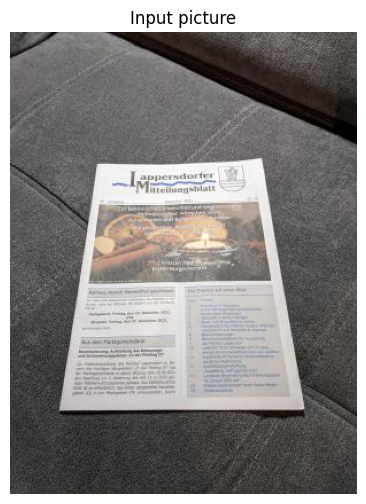

In [4]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = img_rgb

# Solution
_, ax = plt.subplots(figsize=(9, 6))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Input picture")
plt.show()


### Harris Corner Detector
Let us now compute Harris corners. Remember that the Harris detector computes the "cornerness" score for each image pixel.

In [5]:
# Compute Harris corners

import cv2
import numpy as np

# Input data
blockSize = 2
ksize = 3
# k: 0.04–0.06 is typical
k = 0.04
float_min_th = 1e-6
cornerness_th = -7

# Solution
# Convert image to gray scale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
rows, cols = gray.shape
# normalization
gray_n = gray.astype(np.float32) / 255

# Compute Harris corners (use the available OpenCV functions)
cornerness = cv2.cornerHarris(gray_n, blockSize=blockSize, ksize=ksize, k=k)

# We are not interested in edges, so put to zero all negative cornerness values
cornerness_ng = np.where(cornerness < float_min_th, float_min_th, cornerness)
# for testing
# cornerness_ng = np.where(cornerness <= 0.0, float_min_th, cornerness)

# Since cornerness has a huge dynamic range, let's take the logarithm for better visualization and manipulation
cornerness_lg = np.log(cornerness_ng)

# check threshold
cornerness_lg_min = np.min(cornerness_lg)
cropped_cornerness = np.where(cornerness_lg < cornerness_th, cornerness_lg_min, cornerness_lg)

# Print results
images_dict = {
    "Original image": img_rgb,
    "Grayscale image": gray_n,
    "Cornerness by Harris": cornerness,
    "Logarithmic cornerness": cornerness_lg,
    "Cropped cornerness": cropped_cornerness,
}


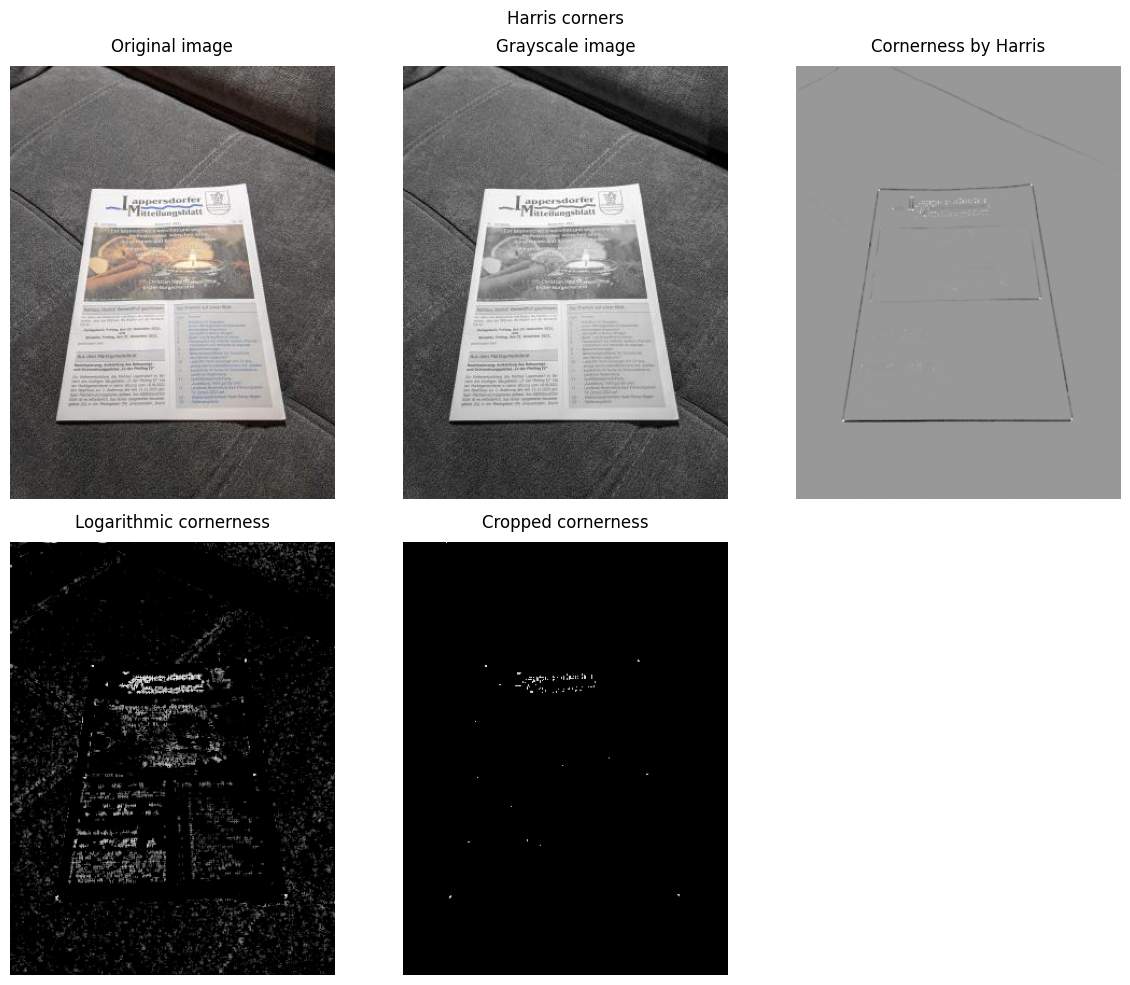

In [6]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 3
images_dict = images_dict
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Harris corners")
plt.tight_layout()
plt.show()


At this point, you can see that the Harris detector has detected a lot of features. Not only the four document corners, but also the corners corresponding to (black) letters printed on (white) paper. How can we filter out everything but the 4 document corners?

For that purpose, let's design a custom feature descriptor suitable to detect the document corners. In order to do so, let's have a look at the top left corner.

![Top-left corner](resources/images/document_descriptor_example.jpg "Top-left corner")

A good descriptor of that corner, given a certain neghbouring region, would be to assess that the bottom-right quadrant is (much) brighter than the other three quadrants (i.e. top-left, top-right, bottom-left). Let's then implement it :-) I'll do the implementation for the top-left corner, you shall do the rest.

In [7]:
# Detection of the corners

# Input data
sign_color = (255, 0, 0)
float_min = np.finfo(np.float32).min
# Detection thresholds
th_top_left, th_top_right = float_min, float_min
th_bottom_left, th_bottom_right = float_min, float_min
# Corner coordinates
opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_right = None, None
# Size of each quadrant (in pixels)
quad_size = 7

# Solution

# Let's now scan the Harris detection results
for r in range(quad_size, rows - quad_size):
    for c in range(quad_size, cols - quad_size):
        # Edges with too small cornerness score are discarded, -7 seems like a good value
        if cropped_cornerness[r, c] < cornerness_th:
            continue

        # Extract block consisting of 4 quadrants
        block = gray[r - quad_size:r + quad_size + 1, c - quad_size:c + quad_size + 1]
        height, width = block.shape

        # Extract the four quadrants
        quad_top_left = block[0:quad_size, 0:quad_size]
        quad_top_right = block[0:quad_size, width - quad_size:width]
        quad_bottom_left = block[height - quad_size:height, 0:quad_size]
        quad_bottom_right = block[height - quad_size:height, width - quad_size:width]

        # For the top-left document corner, the bottom-right quadrant is mostly paper and the rest is
        # darker background. Therefore, I suggest the descriptor to be the average difference between
        # the paper quadrant and the sum of the 3 remaining background quadrants
        # Let's detect the best descriptors
        mean_top_left = np.mean(quad_top_left)
        mean_top_right = np.mean(quad_top_right)
        mean_bottom_left = np.mean(quad_bottom_left)
        mean_bottom_right = np.mean(quad_bottom_right)
        # sum of th all means
        mean_sum = mean_top_left + mean_top_right + mean_bottom_left + mean_bottom_right

        # Top-left corner
        # descriptor = mean_bottom_right - (mean_top_left + mean_top_right + mean_bottom_left) =>
        # => mean_bottom_right - (mean_sum - mean_bottom_right) => 2 * mean_bottom_right - mean_sum
        descriptor = 2 * mean_bottom_right - mean_sum
        if descriptor > th_top_left:
            # We update the threshold
            th_top_left = descriptor
            # And we update the optimal location
            opt_top_left = (c, r)

        # Top-right corner
        descriptor = 2 * mean_bottom_left - mean_sum
        if descriptor > th_top_right:
            # We update the threshold
            th_top_right = descriptor
            # And we update the optimal location
            opt_top_right = (c, r)

        # Bottom-left corner
        descriptor = 2 * mean_top_right - mean_sum
        if descriptor > th_bottom_left:
            # We update the threshold
            th_bottom_left = descriptor
            # And we update the optimal location
            opt_bottom_left = (c, r)

        # Bottom-right corner
        descriptor = 2 * mean_top_left - mean_sum
        if descriptor > th_bottom_right:
            # We update the threshold
            th_bottom_right = descriptor
            # And we update the optimal location
            opt_bottom_right = (c, r)

# Let's draw circles at the detected corners
img_out = img_rgb.copy()
opts = [
    opt_top_left,
    opt_top_right,
    opt_bottom_left,
    opt_bottom_right,
]

for opt in opts:
    if opt is not None:
        img_out = cv2.circle(img_out, opt, 3, sign_color, -1)

# Print results
images_dict.update({
    "Image with detected corners": img_out,
})


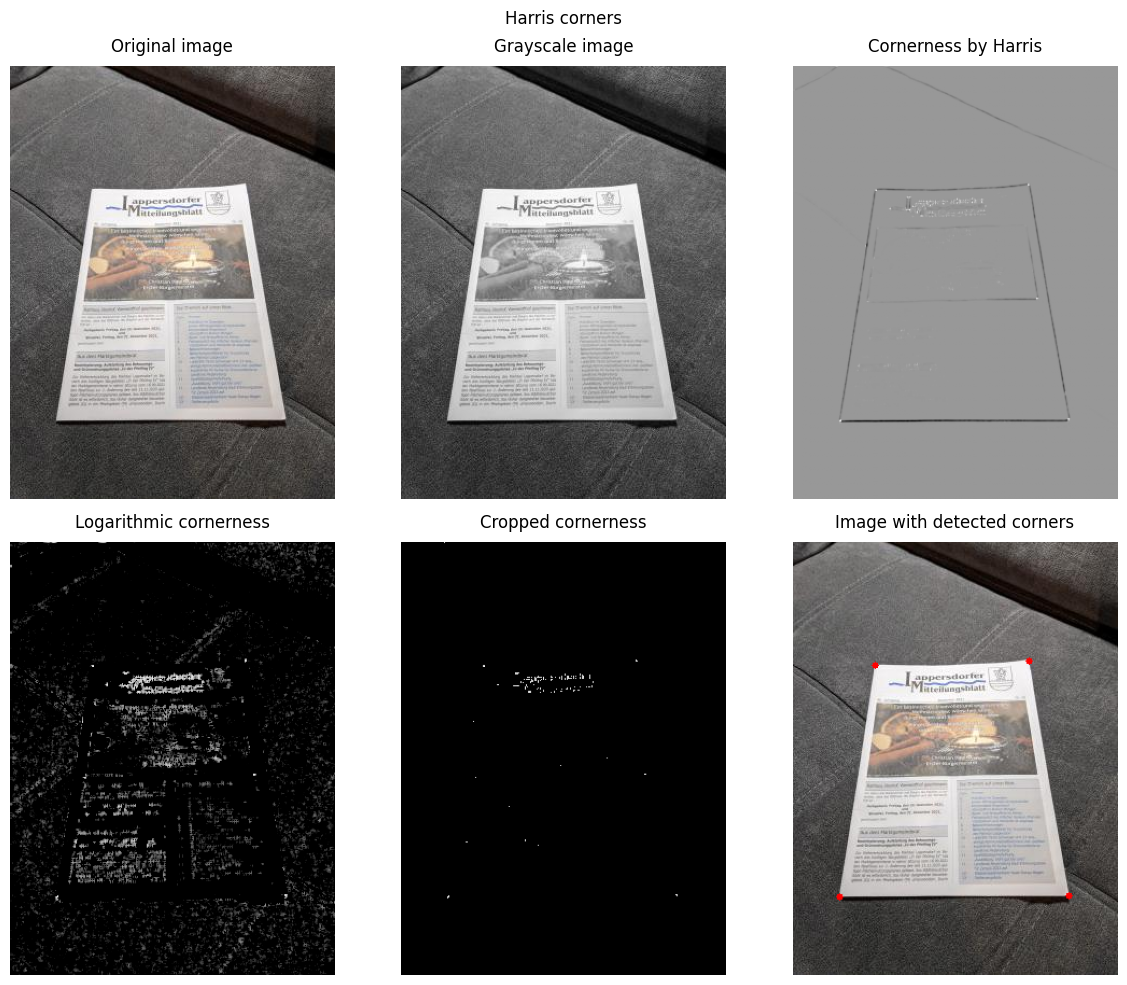

In [8]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 3
images_dict = images_dict
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Harris corners")
plt.tight_layout()
plt.show()


### Questions
* Does it matter whether the picture has been taken by a 1Mpx camera or a 12Mpx camera? How?
* If we increased the resolution of the camera, what would you change in the current algorithm?

Remember, I am **not** looking for a particular answer. I want to see how you think, so be creative ;-)

### Answers
1. Yes, it matters. Computational complexity: A 12Mpx image contains 12 times more pixels than a 1Mpx image. As a result, the nested pixel-by-pixel loops (`for r` and `for c`) will take 12 times longer to execute, severely slowing down the algorithm.Noise and details: High-resolution cameras capture micro-textures (like fabric threads on a sofa or paper grain) and small text elements with high contrast. For the Harris corner detector, these small details will look like thousands of new "false" corners, causing massive noise in the initial processing phase.
2. Assumption: We assume that the field of view (FOV) and the distance to the document remain unchanged; only the pixel density (resolution) increases.
* First part (Harris Detection): We must increase the **blockSize** parameter in `cv2.cornerHarris` (and the Gaussian blur kernel size). Since the document's physical corners now span across more pixels, a larger window is required to detect the global geometry rather than getting stuck on microscopic pixel-level edges or text contrast.
* Second part (Quadrant Descriptor): The changes here depend on the characteristics of the image scaling: **Theoretical scenario** (Perfect sharpness): If we assume that the document edges remain perfectly sharp (transition takes exactly 1 pixel) and the corner coordinates are mathematically exact, then quad_size does not need to be changed. The angular proportions and the ratio of paper-to-background areas inside the quadrants will remain geometrically identical. **Practical scenario** (Real-world blur): In practice, as resolution increases, the optical transition boundary (blur/gradient between paper and background) also widens across more pixels. To prevent this blurred "gray zone" from dominating the small quadrant area and ruining the np.mean() calculations, quad_size must be increased proportionally to the resolution to maintain a stable descriptor ratio.

## Idea for analysis:

## Optimizing Automotive Sensor Calibration by Integrating Optical CAD Data into Computer Vision Algorithms
### Context and Problem Statement:
Modern calibration of automotive optical sensors, such as systems developed at the AVL Mobility and Sensor Center [https://roding-research.avl-functions.com/en/mobility-and-sensor-center/ ], traditionally relies on end-of-line physical test benches equipped with calibration targets (e.g., chessboards or dot grids). The primary goal of this process is to experimentally determine the lens aberrations (mainly distortion) and compensate for them programmatically via Computer Vision to ensure a geometrically accurate image. However, this approach is capital-intensive, requires strict positioning, and takes up critical cycle time on production lines.

### Proposed Innovation:
Since geometric aberrations originate strictly from the physical parameters of the optical assembly (lens radii of curvature, thicknesses, air gaps, and glass refractive indices), they can be perfectly quantified during the R&D stage. I propose to accelerate and automate the calibration pipeline by directly converting nominal data from optical simulation software into calibration coefficients for computer vision algorithms.

### Technical Implementation:
1. **Aberration Modeling**: Utilizing industry-standard optical design software like Ansys Zemax OpticStudio [https://en.wikipedia.org/wiki/Zemax ] or Aber [https://en.wikipedia.org/wiki/Aber_(software) ], an exact digital twin of the lens can be created. Diagnostic features such as Grid Distortion and Geometric Image Analysis [https://simutechgroup.com/resources/blog/geometric-image-analysis-in-zemax/ ] provide precise visualization and mathematical descriptions of the coordinate grid deformation at the image plane.
2. **Accounting for Real-World Physics**: When generating calibration coefficients, it is crucial to account for complex parameters [https://community.zemax.com/got-a-question-7/distortion-and-vignetting-1840 ] and utilize methods for simulating high-resolution images for pixel-accurate mapping [https://optics.ansys.com/hc/en-us/articles/42661994652819-How-to-simulate-high-resolution-images ]. As shown in the webinar Identifying Aberrations with OpticStudio at 06:15 [https://www.youtube.com/watch?v=_1Cq2qVnKws ], the Field Curvature/Distortion metrics provide a comprehensive percentage-based calculation of actual ray displacement relative to reference locations.
3. **Direct Conversion to CV Matrices**: The raw aberration polynomials (e.g., coefficients or ray intercept data) are extracted via the software's API and mathematically mapped onto standard Computer Vision distortion models.

<center>
  <img src="resources/images/Screenshot.png" alt="Grid Distortion" width="500">
</center>

### Key Advantages:
* **Velocity (Reduced Cycle Time)**: The camera module receives a baseline "digital calibration passport" instantly. Physical targets are only needed for final, minor tolerances (compensating for mechanical assembly errors).
* **Expanded Capabilities**: This approach allows for pre-calculating the effects of thermal degradation, mechanical stress, and focal shifts on camera calibration without constructing expensive environmental test chambers.